In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df=pd.read_csv("/Users/bhijanbastola/Desktop/intern/Data/mobile.xls")

In [3]:
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [4]:
df.fc.unique()

array([ 1,  0,  2, 13,  3,  4,  5,  7, 11, 12, 16,  6, 15,  8,  9, 10, 18,
       17, 14, 19])

<Axes: xlabel='price_range', ylabel='count'>

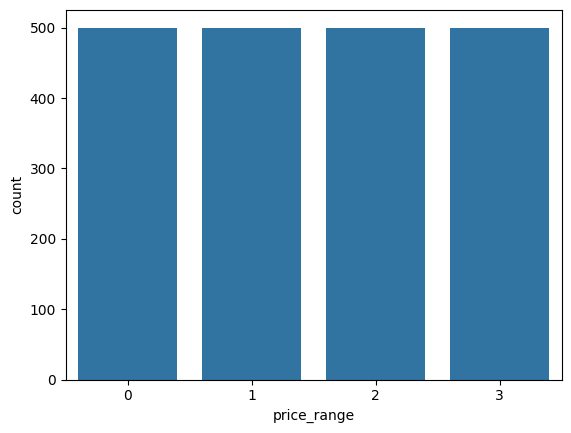

In [12]:
sns.countplot(df,x="price_range")

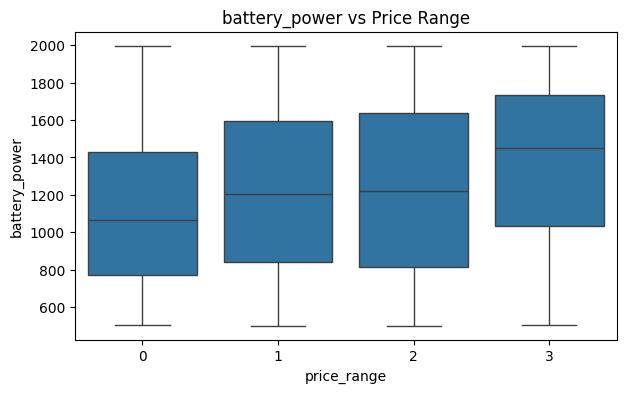

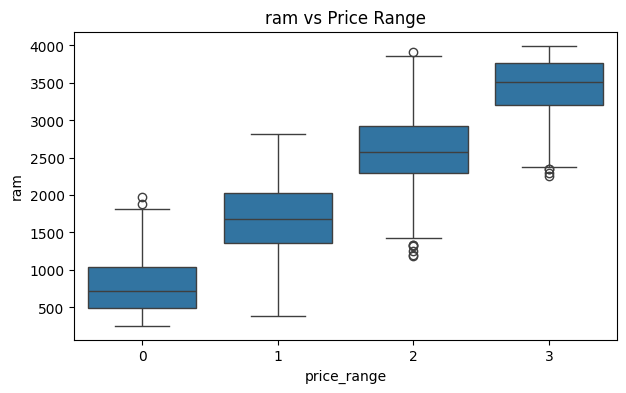

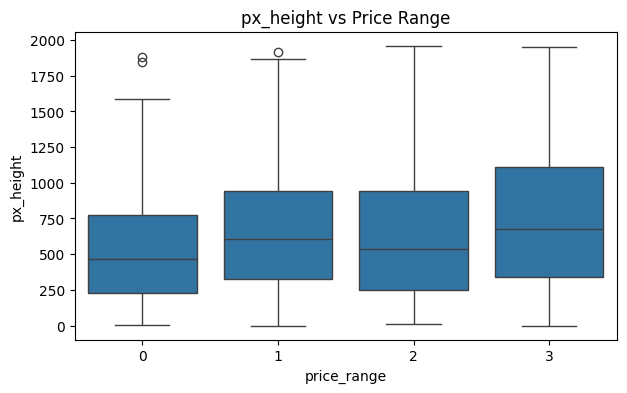

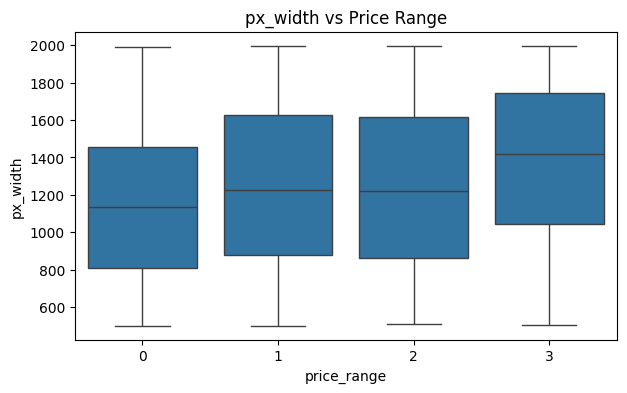

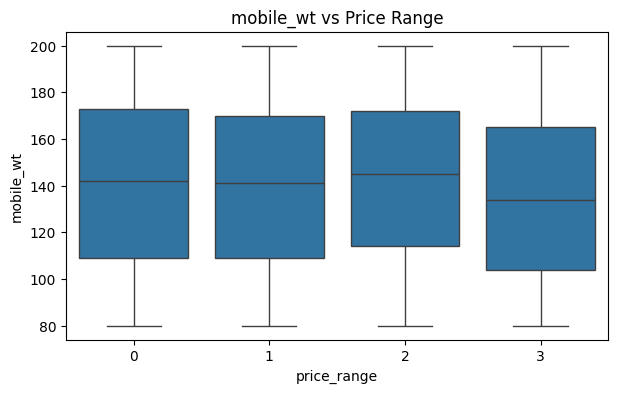

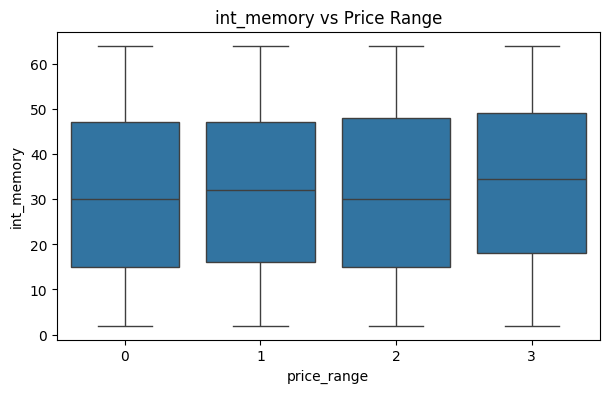

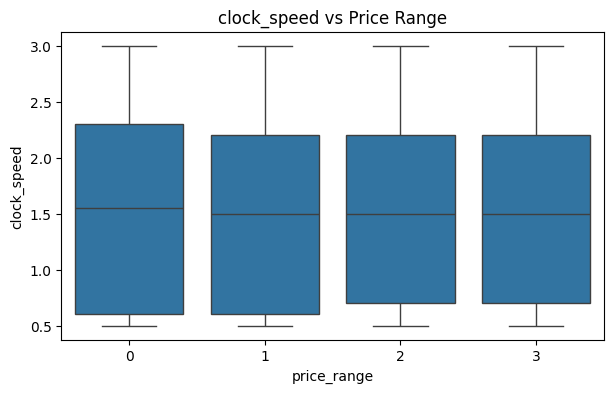

In [6]:
features = ['battery_power', 'ram', 'px_height', 'px_width',
            'mobile_wt', 'int_memory', 'clock_speed']

for col in features:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x='price_range', y=col, data=df)
    plt.title(f'{col} vs Price Range')
    plt.show()

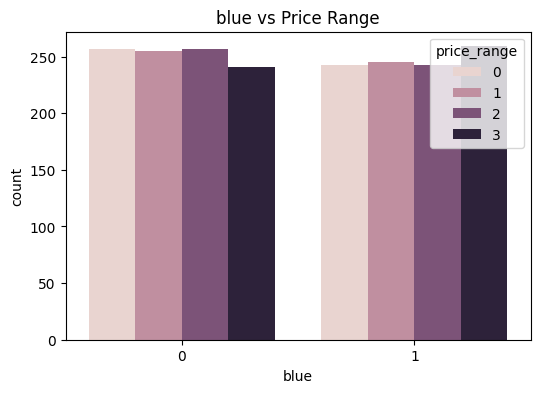

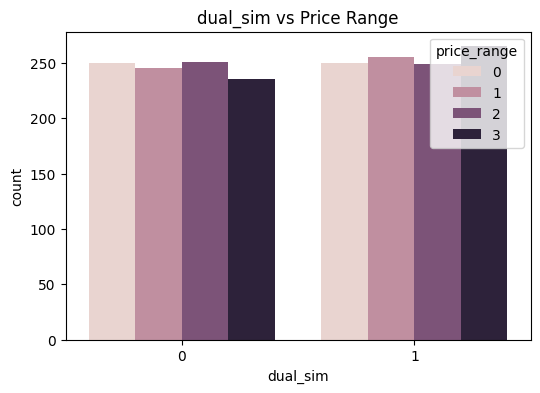

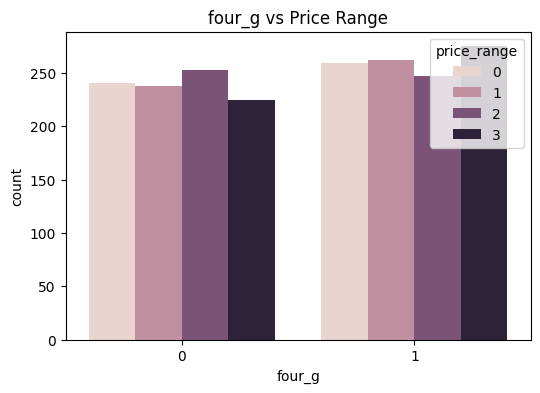

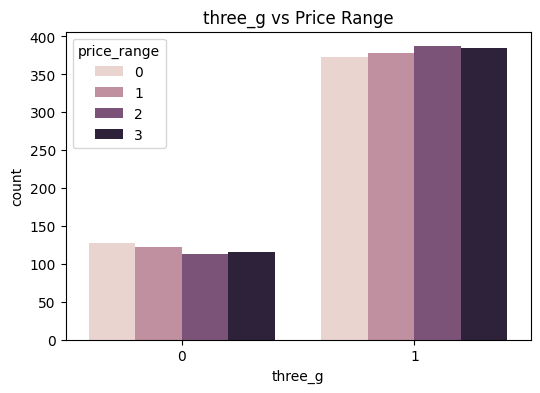

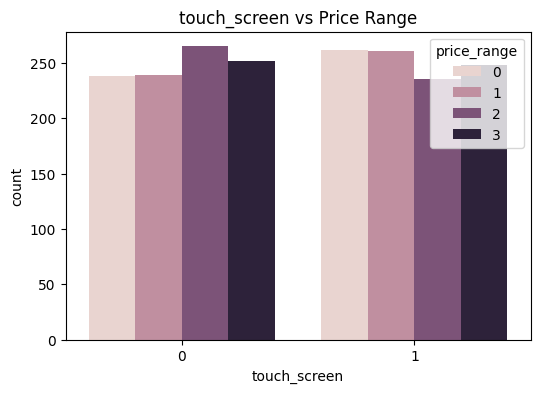

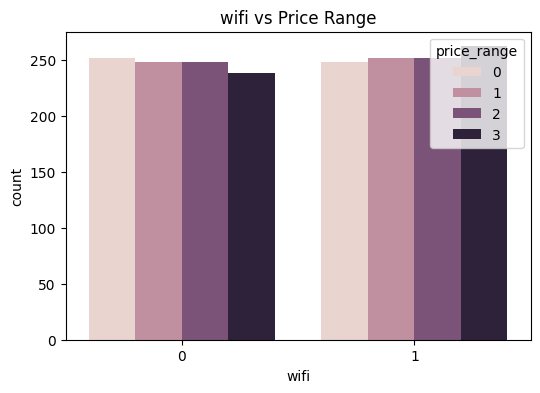

In [7]:
binary_features = [
    'blue', 'dual_sim', 'four_g',
    'three_g', 'touch_screen', 'wifi'
]

for col in binary_features:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, hue='price_range', data=df)
    plt.title(f'{col} vs Price Range')
    plt.show()

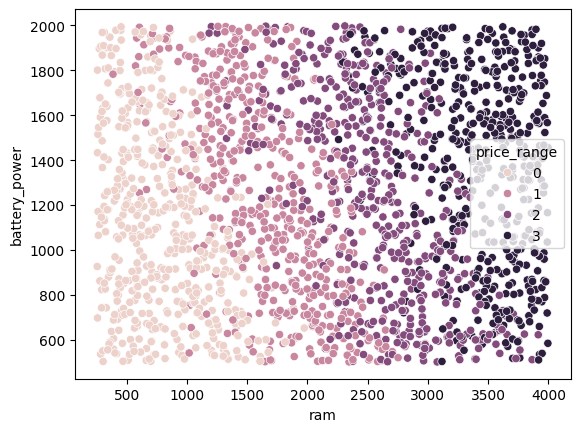

In [8]:
sns.scatterplot(
    x='ram',
    y='battery_power',
    hue='price_range',
    data=df
)

plt.show()

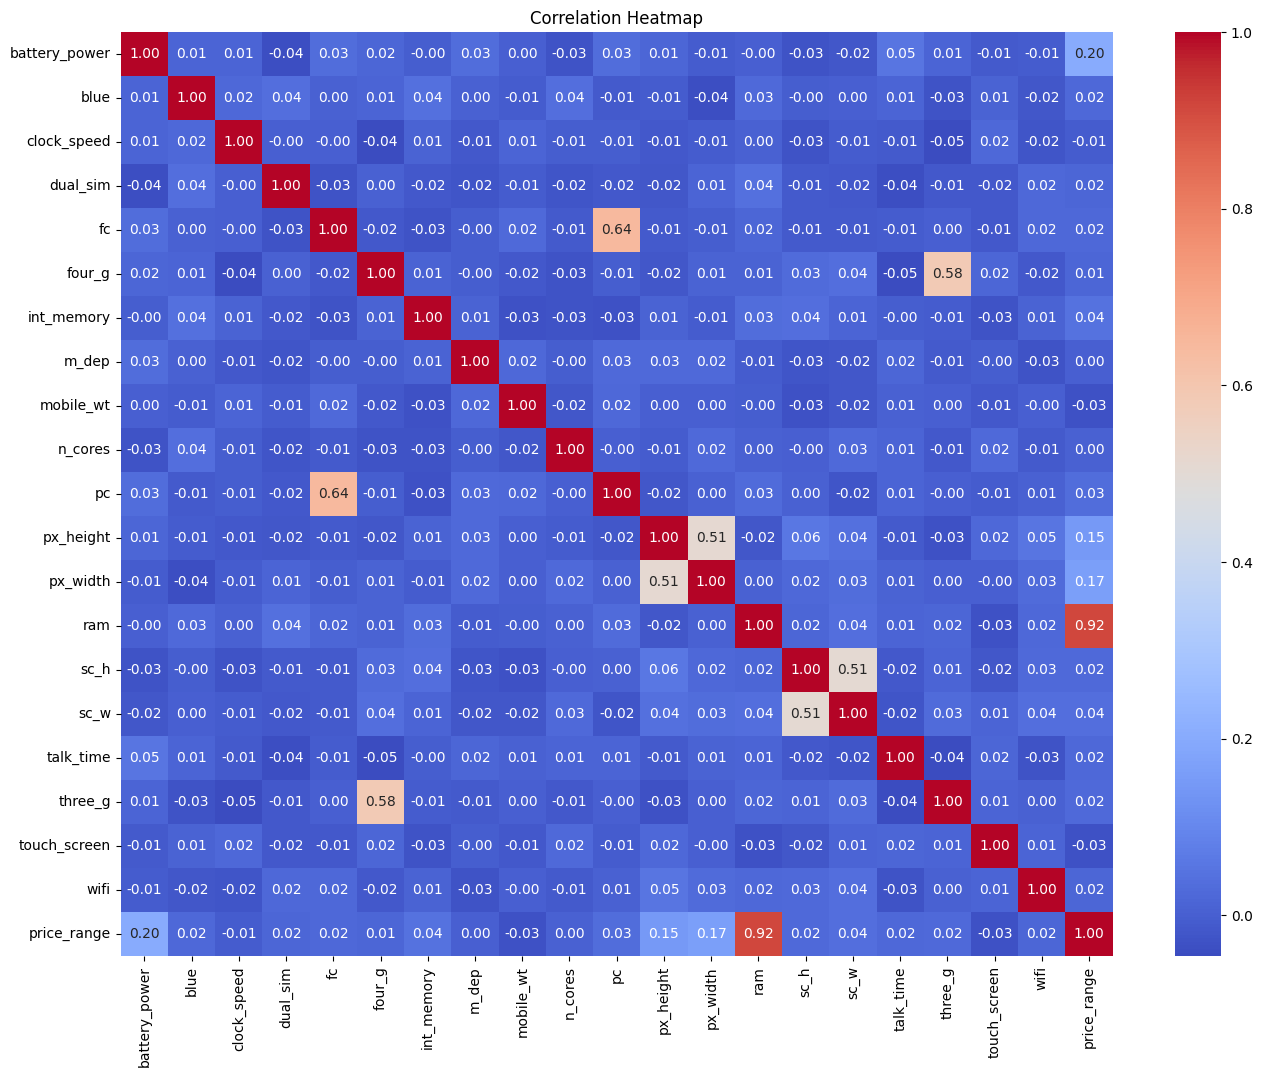

In [9]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

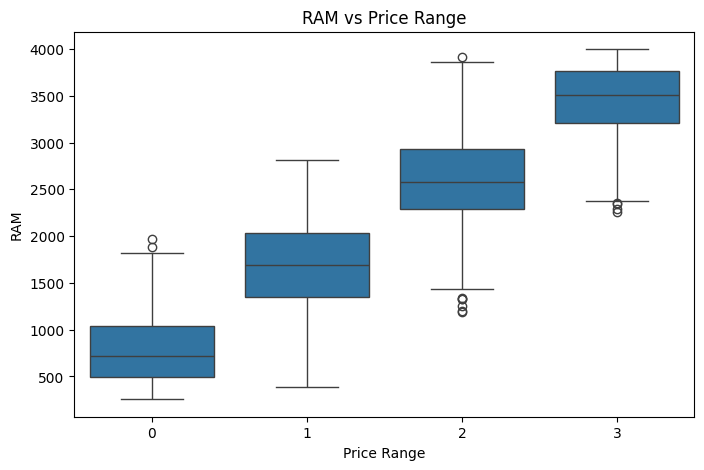

In [10]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x='price_range',
    y='ram',
    data=df
)

plt.title('RAM vs Price Range')
plt.xlabel('Price Range')
plt.ylabel('RAM')
plt.show()

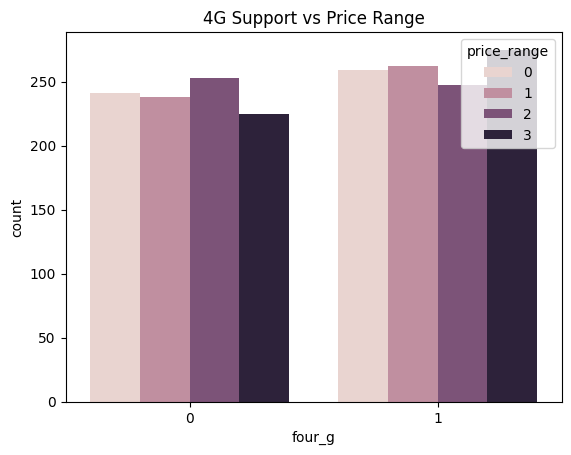

In [13]:
sns.countplot(x='four_g', hue='price_range', data=df)
plt.title('4G Support vs Price Range')
plt.show()

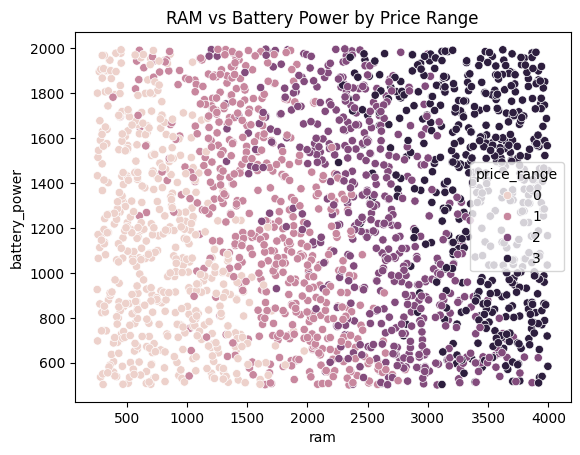

In [14]:
sns.scatterplot(
    x='ram',
    y='battery_power',
    hue='price_range',
    data=df
)

plt.title('RAM vs Battery Power by Price Range')
plt.show()

In [15]:
df.isna().sum()

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
 

In [21]:
X=df.drop("price_range",axis=1)
y=df["price_range"]

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42,stratify=y)

In [24]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [25]:
model=LogisticRegression()

model.fit(X_train_scaled,y_train)
y_pred=model.predict(X_test_scaled)


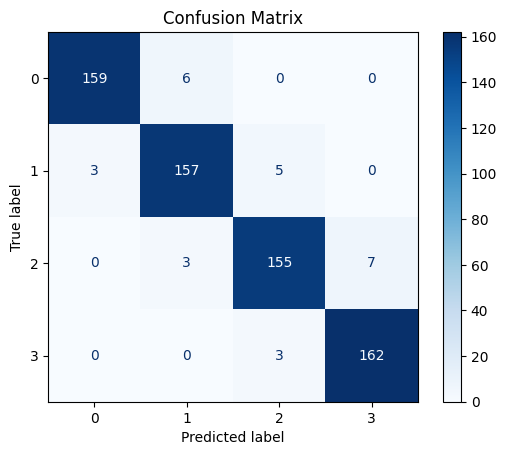

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0, 1, 2, 3]
)

disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

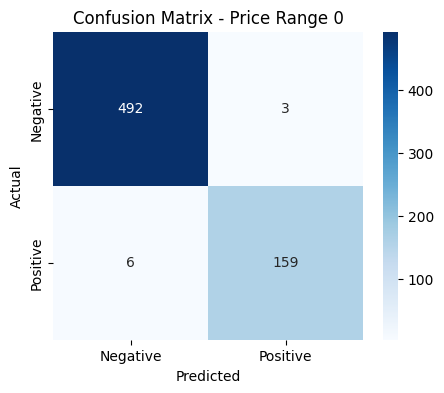

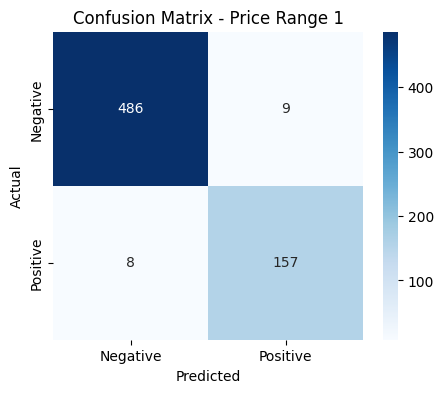

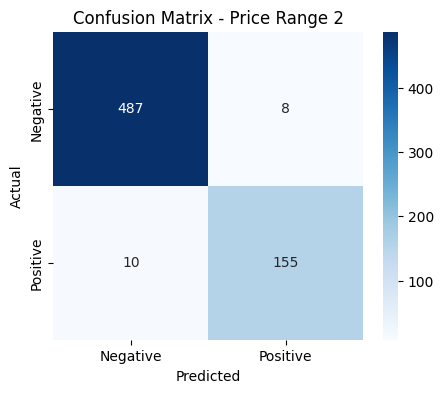

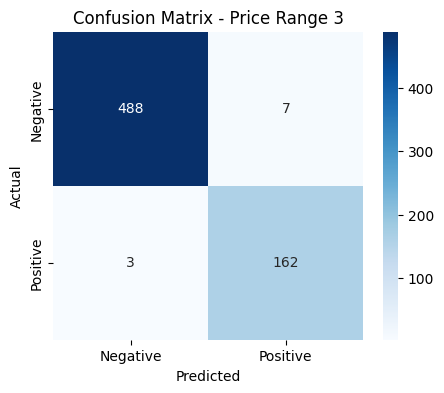

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

for i in range(4):

    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = cm.sum() - (TP + FN + FP)

    binary_cm = [[TN, FP],
                 [FN, TP]]

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        binary_cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Negative', 'Positive'],
        yticklabels=['Negative', 'Positive']
    )

    plt.title(f'Confusion Matrix - Price Range {i}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()